In [369]:
import pandas as pd
import os
import numpy as np

folder = "Metafida"
all_stats = []

filter_cols = [
    "NumbersFilter",
    "WordCountFilter",
    "SymbolsToWordsFilter",
    "UrlsFilter",
    "RepeatingTopNGramsFilter_n=2",
    "RepeatingTopNGramsFilter_n=3",
    "WhiteSpaceFilter",  # both
    "ParenthesesFilter",
    "BoilerPlateStringFilter",
    "RepeatedLinesFilter",  # left-tailed
    "RepeatedParagraphsFilter",  # left-tailed
    "RepeatedLinesByCharFilter",  # left-tailed
    "RepeatedParagraphsByCharFilter",  # left-tailed
    "NonAlphaNumericFilter",  # both
    "BulletsFilter",
    "LongWordFilter",
    "MeanWordLengthFilter",  # both
    "RepeatingDuplicateNGramsFilter_n=2",
    "RepeatingDuplicateNGramsFilter_n=3",
    "PunctuationFilter",  # both
    "EllipsisFilter",
]

EXCLUDE_FILES = {
    "ispac_sl_filter_scores.parquet",
    "eltec_slv_filter_scores.parquet",
    "rsdo5_filter_scores.parquet",
    "prilit_filter_scores.parquet",
}

LEFT_TAILED = {
    "RepeatedLinesFilter",
    "RepeatedParagraphsFilter",
    "RepeatedLinesByCharFilter",
    "RepeatedParagraphsByCharFilter",
}

BOTH_TAILED = {
    "WhiteSpaceFilter",
    "NonAlphaNumericFilter",
    "MeanWordLengthFilter",
    "PunctuationFilter",
}

EPS = 1e-9
SHIFT = 1e-6
LOW_SHIFT_Q = 0.001

for file in os.listdir(folder):
    if not file.endswith(".parquet") or file in EXCLUDE_FILES:
        continue

    df = pd.read_parquet(os.path.join(folder, file))
    stats = {}

    for c in filter_cols:
        need_flip = (c in LEFT_TAILED) or (c in BOTH_TAILED)

        stats[f"{c}__median"] = np.nan
        stats[f"{c}__log_spread"] = np.nan
        stats[f"{c}__log_tail"] = np.nan
        if need_flip:
            stats[f"{c}__log_tail_flip"] = np.nan

        if c not in df.columns:
            continue

        x = df[c].dropna().to_numpy()
        if x.size == 0:
            continue

        # --- median + spread on priginal only ---
        q25, q50, q75 = np.quantile(x, [0.25, 0.50, 0.75])
        stats[f"{c}__median"] = q50
        stats[f"{c}__log_spread"] = np.log1p(max(q75 - q25, 0.0))

        def log_tail_right(v: np.ndarray) -> float:
            vlo = np.quantile(v, LOW_SHIFT_Q)
            z = v - vlo + SHIFT
            z50, z99 = np.quantile(z, [0.50, 0.99])
            return float(np.log(z99 + EPS) - np.log(z50 + EPS))

        # --- log_tail on original ---
        stats[f"{c}__log_tail"] = log_tail_right(x)

        # --- log_tail on flip ---
        if need_flip:
            stats[f"{c}__log_tail_flip"] = log_tail_right(-x)

    row = pd.Series(stats, name=file.split("_filter_")[0])
    all_stats.append(row)

stats_df = pd.DataFrame(all_stats)
print(stats_df.head())

              NumbersFilter__median  NumbersFilter__log_spread  \
janes_norm30               0.000000                   0.014389   
siparl30                   0.004192                   0.002893   
janes_news                 0.000000                   0.000000   
jaslo_sl                   0.005744                   0.014100   
janes_forum                0.000000                   0.009119   

              NumbersFilter__log_tail  WordCountFilter__median  \
janes_norm30                11.673203                     11.0   
siparl30                     1.445089                  13052.0   
janes_news                  11.745549                     24.0   
jaslo_sl                     2.828154                    948.5   
janes_forum                 11.942715                     27.0   

              WordCountFilter__log_spread  WordCountFilter__log_tail  \
janes_norm30                     2.639057                   1.634130   
siparl30                         9.809754                   1.

In [370]:
#bullet and punctuation have really weird distributions, word count is not very useful for grouping, the rest don't vary at all 
excluded_filters = ("BulletsFilter", "WordCountFilter", "RepeatedLinesFilter", "RepeatedParagraphsFilter", "RepeatedLinesByCharFilter", "RepeatedParagraphsByCharFilter", "BoilerplateStringFilter", "PunctuationFilter")  
stats_df = stats_df.loc[:, ~stats_df.columns.str.startswith(excluded_filters)] 

#exclude_patterns = ("janes", "tweet", "dgt", "classla", "jezkor")

#mask = ~stats_df.index.str.lower().str.contains("|".join(exclude_patterns))
#stats_df = stats_df[mask]



In [371]:
from sklearn.preprocessing import RobustScaler
import hdbscan

X = stats_df.fillna(stats_df.median())
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,
    min_samples=3,     
    metric="euclidean",
    cluster_selection_method="eom" 
)

labels = clusterer.fit_predict(X_scaled)           
probs = clusterer.probabilities_                   
outlier = clusterer.outlier_scores_                

stats_df = stats_df.copy()
stats_df["hdb_label"] = labels
stats_df["hdb_prob"] = probs
stats_df["hdb_outlier"] = outlier

print("Cluster sizes (HDBSCAN):")
print(stats_df["hdb_label"].value_counts().sort_index())

for lab in sorted(stats_df["hdb_label"].unique()):
    members = stats_df.index[stats_df["hdb_label"] == lab].tolist()
    if lab == -1:
        print(f"\nNoise / outliers (-1): {members}")
    else:
        print(f"\nCluster {lab}: {members}")


Cluster sizes (HDBSCAN):
hdb_label
-1     2
 0     7
 1    21
Name: count, dtype: int64

Noise / outliers (-1): ['jezkor', 'dgt15_sl']

Cluster 0: ['janes_norm30', 'janes_news', 'janes_forum', 'janes_wiki', 'tweet_sl', 'janes_tweet', 'janes_blog']

Cluster 1: ['siparl30', 'jaslo_sl', 'maj68', 'maks', 'filmi', 'imp', 'korp', 'konji', 'slwac', 'dsi', 'sbsj', 'gfida20', 'suss', 'vayna', 'trendi', 'gos20', 'solar30_orig', 'kost10_orig', 'classlawiki_sl', 'trans5_sl', 'lemonde_sl']


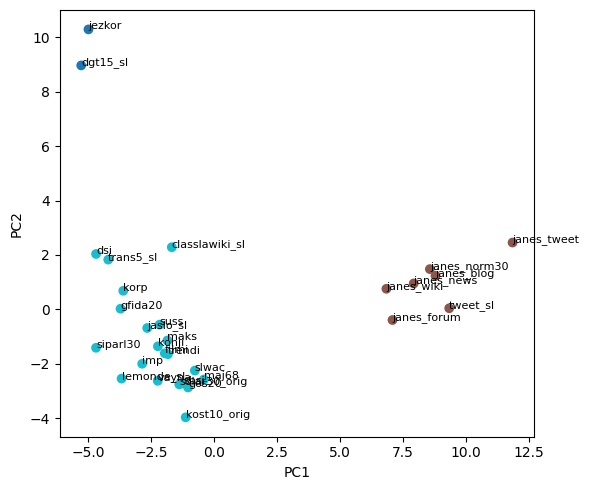

Explained variance ratio: [0.47523999 0.18560195]


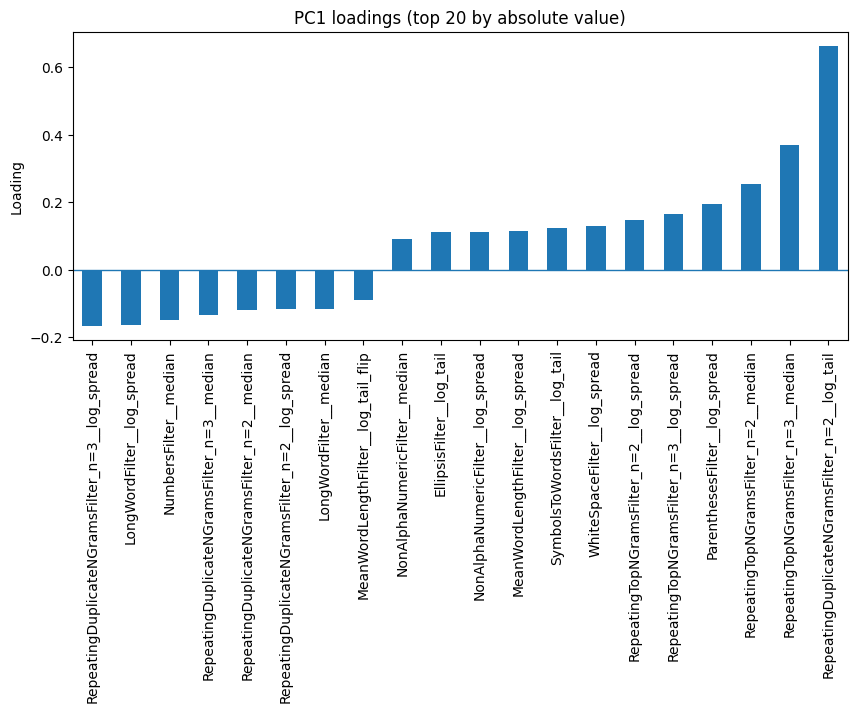

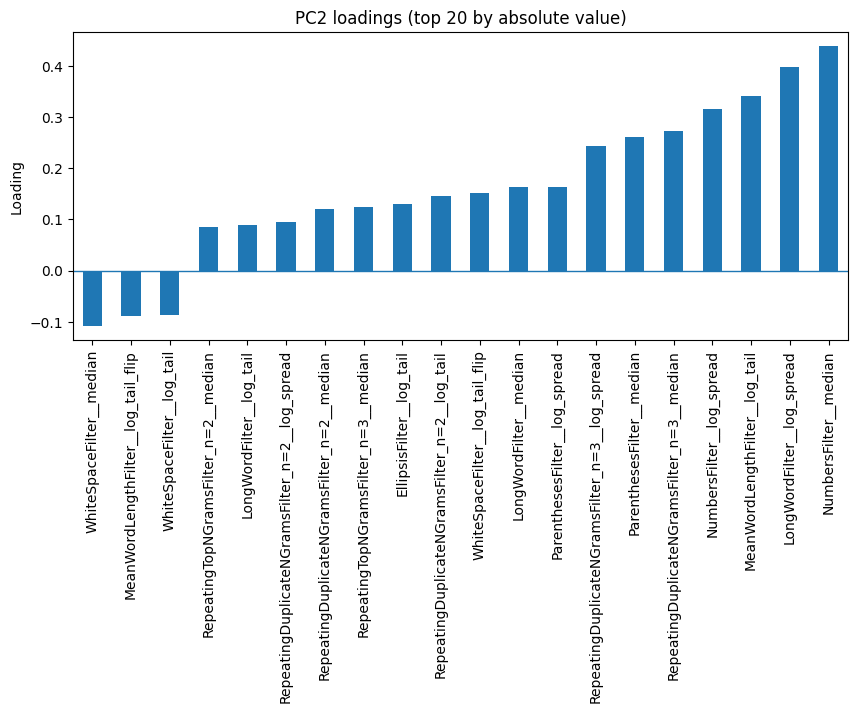

In [372]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler 
from sklearn.decomposition import PCA

# --- data ---
cols = [c for c in stats_df.columns if c not in ["id", "cluster", "hdb_prob", "hdb_outlier", "hdb_label"]]
X = stats_df[cols].fillna(stats_df[cols].median())

# --- scale ---
scaler = RobustScaler()                 
pca_matrix = X
X_scaled = scaler.fit_transform(pca_matrix)

# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- plot ---
labels = stats_df.index
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=stats_df["hdb_label"], cmap="tab10")
for i, name in enumerate(labels):
    plt.text(X_pca[i, 0], X_pca[i, 1], name, fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# --- Loadings ---
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_matrix.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print("Explained variance ratio:", pca.explained_variance_ratio_)

def plot_loadings(loadings_df, pc="PC1", top_n=20):
    vals = loadings_df[pc].sort_values(key=np.abs, ascending=False).head(top_n)
    plt.figure(figsize=(10, 4))
    vals.sort_values().plot(kind="bar")
    plt.axhline(0, linewidth=1)
    plt.title(f"{pc} loadings (top {top_n} by absolute value)")
    plt.ylabel("Loading")
    plt.show()

plot_loadings(loadings, "PC1", top_n=20)
plot_loadings(loadings, "PC2", top_n=20)



In [373]:
baseline_ids = stats_df.index[stats_df["hdb_label"] == 1].tolist()
print("Baseline corpora:", baseline_ids)
print("N baseline:", len(baseline_ids))

Baseline corpora: ['siparl30', 'jaslo_sl', 'maj68', 'maks', 'filmi', 'imp', 'korp', 'konji', 'slwac', 'dsi', 'sbsj', 'gfida20', 'suss', 'vayna', 'trendi', 'gos20', 'solar30_orig', 'kost10_orig', 'classlawiki_sl', 'trans5_sl', 'lemonde_sl']
N baseline: 21


In [374]:
import os

def variability_score(vals):
    """Relative disagreement across clean corpora: MAD / |median|."""
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.inf
    med = np.median(vals)
    mad = np.median(np.abs(vals - med))
    return mad / (abs(med) + 1e-9)


def collect_thresholds(folder, baseline_ids, cols, left_tailed, both_tailed, q_doc=0.99):
    """Per clean corpus: compute q99 (or q01) thresholds for each filter."""
    hi = {c: [] for c in cols}
    lo = {c: [] for c in cols}

    for file in os.listdir(folder):
        if not file.endswith(".parquet"):
            continue
        corpus_id = file.split("_filter_")[0]
        if corpus_id not in baseline_ids:
            continue

        df = pd.read_parquet(os.path.join(folder, file), columns=cols)

        for c in cols:
            x = pd.to_numeric(df[c]).dropna().to_numpy()
            if x.size == 0:
                continue

            if c in left_tailed:
                lo[c].append(float(np.quantile(x, 1.0 - q_doc)))
            elif c in both_tailed:
                lo[c].append(float(np.quantile(x, 1.0 - q_doc)))
                hi[c].append(float(np.quantile(x, q_doc)))
            else:
                hi[c].append(float(np.quantile(x, q_doc)))

    return hi, lo


def choose_permissiveness(cols, left_tailed, both_tailed, hi, lo,
                          qcorp_min=0.80, qcorp_max=0.98):
    """More disagreement across clean corpora => more permissive."""
    var = {}
    for c in cols:
        vals = []
        if c in left_tailed or c in both_tailed:
            vals += lo[c]
        if c not in left_tailed:
            vals += hi[c]
        var[c] = variability_score(np.asarray(vals, float))

    v = np.asarray(list(var.values()), float)
    v_min, v_max = np.min(v), np.max(v)

    q_corp = {}
    for c, vs in var.items():
        if not np.isfinite(vs) or v_max == v_min:
            q_corp[c] = (qcorp_min + qcorp_max) / 2.0
        else:
            t = (vs - v_min) / (v_max - v_min)
            q_corp[c] = qcorp_min + t * (qcorp_max - qcorp_min)

    return q_corp


def aggregate_thresholds(cols, left_tailed, both_tailed, hi, lo, q_corp):
    """Aggregate per-corpus thresholds into one threshold per filter."""
    hi_final, lo_final = {}, {}

    for c in cols:
        qc = q_corp[c]

        if c in left_tailed:
            vals = np.asarray(lo[c], float)
            lo_final[c] = float(np.quantile(vals, 1.0 - qc)) 

        elif c in both_tailed:
            vals_lo = np.asarray(lo[c], float)
            vals_hi = np.asarray(hi[c], float)
            lo_final[c] = float(np.quantile(vals_lo, 1.0 - qc)) 
            hi_final[c] = float(np.quantile(vals_hi, qc)) 

        else:
            vals = np.asarray(hi[c], float)
            hi_final[c] = float(np.quantile(vals, qc)) 

    return pd.Series(hi_final, name="T_hi").sort_index(), pd.Series(lo_final, name="T_lo").sort_index()
    

In [376]:
hi, lo = collect_thresholds("Metafida", baseline_ids, filter_cols, LEFT_TAILED, BOTH_TAILED, q_doc=0.99)
q_corp = choose_permissiveness(filter_cols, LEFT_TAILED, BOTH_TAILED, hi, lo)
T_hi, T_lo = aggregate_thresholds(filter_cols, LEFT_TAILED, BOTH_TAILED, hi, lo, q_corp)

print("q_corp per filter:")
print(pd.Series(q_corp))

print("\nUpper thresholds:")
print(T_hi.dropna())

print("\nLower thresholds:")
print(T_lo.dropna())

q_corp per filter:
NumbersFilter                         0.899243
WordCountFilter                       0.946885
SymbolsToWordsFilter                  0.934104
UrlsFilter                            0.980000
RepeatingTopNGramsFilter_n=2          0.863521
RepeatingTopNGramsFilter_n=3          0.865192
WhiteSpaceFilter                      0.826648
ParenthesesFilter                     0.841646
BoilerPlateStringFilter               0.800000
RepeatedLinesFilter                   0.800000
RepeatedParagraphsFilter              0.800000
RepeatedLinesByCharFilter             0.800000
RepeatedParagraphsByCharFilter        0.800000
NonAlphaNumericFilter                 0.833496
BulletsFilter                         0.800000
LongWordFilter                        0.864904
MeanWordLengthFilter                  0.832724
RepeatingDuplicateNGramsFilter_n=2    0.852629
RepeatingDuplicateNGramsFilter_n=3    0.855248
PunctuationFilter                     0.980000
EllipsisFilter                        0.9